In [2]:
# Cell 1: Install required packages
!pip install timm einops scikit-image gradio -q

**Imports & Config**

In [26]:
# Cell 2: Imports & Global Config
import os
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from einops import rearrange
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
from PIL import Image

# ── Reproducibility ──────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# ── Config ───────────────────────────────────────────────────────
class CFG:
    image_size    = 224
    patch_size    = 16
    num_patches   = (224 // 16) ** 2          # 196
    mask_ratio    = 0.75                       # mask 75%
    visible_n     = int(196 * 0.25)            # 49 visible patches

    # Encoder (ViT-Base)
    enc_dim       = 768
    enc_layers    = 12
    enc_heads     = 12

    # Decoder (ViT-Small)
    dec_dim       = 384
    dec_layers    = 12
    dec_heads     = 6

    # Training
    epochs        = 25
    batch_size    = 64
    lr            = 1.5e-4
    weight_decay  = 0.05
    grad_clip     = 1.0

    data_dir = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200"
    device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {CFG.device}")
print(f"Visible patches: {CFG.visible_n} / {CFG.num_patches}")

Device: cuda
Visible patches: 49 / 196


**Dataset Loader**

In [27]:
# Cell 3: TinyImageNet DataLoader (FULLY FIXED)
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets

train_transform = transforms.Compose([
    transforms.Resize((CFG.image_size, CFG.image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((CFG.image_size, CFG.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Custom Val Dataset ───────────────────────────────────────────
class TinyImageNetVal(Dataset):
    """
    Val structure:
    val/
      images/   ← all images here (flat)
      val_annotations.txt
    """
    def __init__(self, val_dir, transform=None):
        self.transform = transform
        self.img_dir   = os.path.join(val_dir, "images")
        ann_file       = os.path.join(val_dir, "val_annotations.txt")

        self.samples      = []
        self.class_to_idx = {}
        idx = 0

        with open(ann_file, "r") as f:
            for line in f:
                parts = line.strip().split("\t")
                fname, cls = parts[0], parts[1]
                if cls not in self.class_to_idx:
                    self.class_to_idx[cls] = idx
                    idx += 1
                img_path = os.path.join(self.img_dir, fname)
                if os.path.exists(img_path):
                    self.samples.append((img_path, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label = self.samples[index]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Train Dataset ────────────────────────────────────────────────
# Train structure: train/n01443537/images/img1.JPEG
# ImageFolder won't work directly because of the extra /images/ subfolder
# So we use a custom approach

class TinyImageNetTrain(Dataset):
    def __init__(self, train_dir, transform=None):
        self.transform    = transform
        self.samples      = []
        self.class_to_idx = {}
        idx = 0

        for cls in sorted(os.listdir(train_dir)):
            cls_path = os.path.join(train_dir, cls, "images")
            if not os.path.isdir(cls_path):
                continue
            if cls not in self.class_to_idx:
                self.class_to_idx[cls] = idx
                idx += 1
            for fname in os.listdir(cls_path):
                if fname.lower().endswith((".jpeg", ".jpg", ".png")):
                    self.samples.append(
                        (os.path.join(cls_path, fname),
                         self.class_to_idx[cls])
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label = self.samples[index]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Build Datasets ───────────────────────────────────────────────
train_dataset = TinyImageNetTrain(
    os.path.join(CFG.data_dir, "train"),
    transform=train_transform
)

val_dataset = TinyImageNetVal(
    os.path.join(CFG.data_dir, "val"),
    transform=val_transform
)

# ── DataLoaders ──────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset, batch_size=CFG.batch_size,
    shuffle=True,  num_workers=4,
    pin_memory=True, drop_last=True
)

val_loader = DataLoader(
    val_dataset,   batch_size=CFG.batch_size,
    shuffle=False, num_workers=4,
    pin_memory=True, drop_last=True
)

print(f"✅ Train samples : {len(train_dataset)}")
print(f"✅ Val   samples : {len(val_dataset)}")
print(f"✅ Train batches : {len(train_loader)}")
print(f"✅ Val   batches : {len(val_loader)}")

✅ Train samples : 100000
✅ Val   samples : 10000
✅ Train batches : 1562
✅ Val   batches : 156


**Building Blocks (Attention, MLP, Transformer Block)**

In [28]:
# Cell 4: Core Transformer Building Blocks

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads, dropout=0.0):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.qkv  = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(x)


class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MultiHeadSelfAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = MLP(dim, mlp_ratio, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

**Patchify / Unpatchify Utilities**

In [29]:
# Cell 5: Patchify & Unpatchify

def patchify(imgs, patch_size=16):
    """imgs: (B, 3, H, W) → patches: (B, N, patch_size²×3)"""
    B, C, H, W = imgs.shape
    p = patch_size
    h = H // p; w = W // p
    x = imgs.reshape(B, C, h, p, w, p)
    x = x.permute(0, 2, 4, 1, 3, 5)        # (B, h, w, C, p, p)
    x = x.reshape(B, h * w, C * p * p)
    return x                                 # (B, 196, 768)


def unpatchify(patches, patch_size=16, img_size=224):
    """patches: (B, N, patch_size²×3) → imgs: (B, 3, H, W)"""
    B, N, D = patches.shape
    p = patch_size
    C = 3
    h = w = img_size // p
    x = patches.reshape(B, h, w, C, p, p)
    x = x.permute(0, 3, 1, 4, 2, 5)        # (B, C, h, p, w, p)
    x = x.reshape(B, C, img_size, img_size)
    return x


def random_masking(x, mask_ratio=0.75):
    """
    x: (B, N, D) visible token embeddings
    Returns: x_visible, mask, ids_restore
    """
    B, N, D = x.shape
    keep_n  = int(N * (1 - mask_ratio))     # 49

    noise   = torch.rand(B, N, device=x.device)
    ids_shuffle  = torch.argsort(noise, dim=1)
    ids_restore  = torch.argsort(ids_shuffle, dim=1)

    ids_keep     = ids_shuffle[:, :keep_n]  # (B, 49)
    x_visible    = torch.gather(x, 1,
                    ids_keep.unsqueeze(-1).expand(-1, -1, D))  # (B, 49, D)

    # Binary mask: 1=masked, 0=visible
    mask = torch.ones(B, N, device=x.device)
    mask[:, :keep_n] = 0
    mask = torch.gather(mask, 1, ids_restore)

    return x_visible, mask, ids_restore

**MAE Encoder**

In [30]:
# Cell 6: MAE Encoder (ViT-Base) - FIXED

class MAEEncoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16,
                 dim=768, depth=12, num_heads=12):
        super().__init__()
        self.patch_size  = patch_size
        self.num_patches = (img_size // patch_size) ** 2   # 196
        patch_dim        = 3 * patch_size * patch_size     # 768

        self.patch_embed = nn.Linear(patch_dim, dim)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed   = nn.Parameter(
            torch.zeros(1, self.num_patches + 1, dim), requires_grad=False)

        self._init_pos_embed(dim)

        self.blocks = nn.ModuleList([
            TransformerBlock(dim, num_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(dim)
        self._init_weights()

    def _init_pos_embed(self, embed_dim):
        grid_size = int(self.num_patches ** 0.5)   # 14
        pos_embed = self._get_sincos_pos_embed(embed_dim, grid_size)
        self.pos_embed.data.copy_(
            torch.from_numpy(pos_embed).float().unsqueeze(0))

    @staticmethod
    def _get_sincos_pos_embed(embed_dim, grid_size):
        """
        embed_dim: total dimension (768)
        grid_size: number of patches per side (14)
        Returns: (grid_size*grid_size + 1, embed_dim)
        """
        # Each axis gets half the dimensions
        assert embed_dim % 4 == 0, "embed_dim must be divisible by 4"
        half_dim = embed_dim // 4   # 192 per axis sin/cos

        # Frequency bands
        omega = np.arange(half_dim, dtype=np.float32) / half_dim
        omega = 1.0 / (10000 ** omega)   # (half_dim,)

        # Grid positions
        grid_h = np.arange(grid_size, dtype=np.float32)
        grid_w = np.arange(grid_size, dtype=np.float32)
        grid_h, grid_w = np.meshgrid(grid_h, grid_w, indexing='ij')
        grid_h = grid_h.reshape(-1)   # (196,)
        grid_w = grid_w.reshape(-1)   # (196,)

        # Outer product: position x frequency
        emb_h = grid_h[:, None] * omega[None, :]   # (196, 192)
        emb_w = grid_w[:, None] * omega[None, :]   # (196, 192)

        # Sin/cos for each axis
        emb = np.concatenate([
            np.sin(emb_h),   # (196, 192)
            np.cos(emb_h),   # (196, 192)
            np.sin(emb_w),   # (196, 192)
            np.cos(emb_w),   # (196, 192)
        ], axis=1)           # (196, 768)

        # Prepend CLS token (zeros)
        cls_emb = np.zeros((1, embed_dim), dtype=np.float32)
        emb = np.concatenate([cls_emb, emb], axis=0)   # (197, 768)

        return emb

    def _init_weights(self):
        nn.init.normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, imgs):
        # 1. Patchify
        patches = patchify(imgs, self.patch_size)      # (B, 196, 768)

        # 2. Embed patches
        x = self.patch_embed(patches)                  # (B, 196, 768)

        # 3. Add positional embedding (no cls token yet)
        x = x + self.pos_embed[:, 1:, :]

        # 4. Random masking → keep only 49 visible patches
        x_vis, mask, ids_restore = random_masking(x, CFG.mask_ratio)

        # 5. Prepend CLS token with its positional embedding
        cls = self.cls_token.expand(x_vis.shape[0], -1, -1)
        cls = cls + self.pos_embed[:, :1, :]
        x_vis = torch.cat([cls, x_vis], dim=1)         # (B, 50, 768)

        # 6. Transformer blocks
        for blk in self.blocks:
            x_vis = blk(x_vis)
        x_vis = self.norm(x_vis)

        return x_vis, mask, ids_restore

**MAE Decoder**

In [31]:
# Cell 7: MAE Decoder (ViT-Small) - FIXED

class MAEDecoder(nn.Module):
    def __init__(self, num_patches=196, patch_size=16,
                 enc_dim=768, dec_dim=384, depth=12, num_heads=6):
        super().__init__()
        patch_dim = 3 * patch_size * patch_size   # 768

        self.proj       = nn.Linear(enc_dim, dec_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_dim))
        self.pos_embed  = nn.Parameter(
            torch.zeros(1, num_patches + 1, dec_dim), requires_grad=False)

        self._init_pos_embed(dec_dim, num_patches)

        self.blocks = nn.ModuleList([
            TransformerBlock(dec_dim, num_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(dec_dim)
        self.pred = nn.Linear(dec_dim, patch_dim)
        self._init_weights()

    def _init_pos_embed(self, embed_dim, num_patches):
        assert embed_dim % 4 == 0, "embed_dim must be divisible by 4"
        grid_size = int(num_patches ** 0.5)   # 14
        pos_embed = MAEEncoder._get_sincos_pos_embed(embed_dim, grid_size)
        self.pos_embed.data.copy_(
            torch.from_numpy(pos_embed).float().unsqueeze(0))

    def _init_weights(self):
        nn.init.normal_(self.mask_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, enc_tokens, ids_restore):
        B = enc_tokens.shape[0]
        N = ids_restore.shape[1]        # 196

        # 1. Project encoder dim → decoder dim
        x = self.proj(enc_tokens)       # (B, 50, 384)

        # 2. Number of masked tokens
        num_vis  = x.shape[1] - 1       # 49 (exclude CLS)
        num_mask = N - num_vis          # 147

        # 3. Expand mask tokens
        mask_tokens = self.mask_token.expand(B, num_mask, -1)  # (B, 147, 384)

        # 4. Concatenate visible + mask, then unshuffle to original order
        x_no_cls = x[:, 1:, :]         # (B, 49, 384)
        x_ = torch.cat([x_no_cls, mask_tokens], dim=1)         # (B, 196, 384)
        x_ = torch.gather(x_, 1,
               ids_restore.unsqueeze(-1).expand(-1, -1, x_.shape[-1]))

        # 5. Prepend CLS token
        x = torch.cat([x[:, :1, :], x_], dim=1)   # (B, 197, 384)

        # 6. Add positional embedding
        x = x + self.pos_embed

        # 7. Transformer blocks
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)

        # 8. Predict pixels (remove CLS)
        x = self.pred(x[:, 1:, :])     # (B, 196, 768)
        return x

**Full MAE Model**

In [32]:
# Cell 8: Full MAE Model

class MAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MAEEncoder(
            img_size=CFG.image_size, patch_size=CFG.patch_size,
            dim=CFG.enc_dim, depth=CFG.enc_layers, num_heads=CFG.enc_heads)
        self.decoder = MAEDecoder(
            num_patches=CFG.num_patches, patch_size=CFG.patch_size,
            enc_dim=CFG.enc_dim, dec_dim=CFG.dec_dim,
            depth=CFG.dec_layers, num_heads=CFG.dec_heads)

    def forward(self, imgs):
        enc_tokens, mask, ids_restore = self.encoder(imgs)
        pred = self.decoder(enc_tokens, ids_restore)
        loss = self.compute_loss(imgs, pred, mask)
        return loss, pred, mask

    def compute_loss(self, imgs, pred, mask):
        target = patchify(imgs, CFG.patch_size)
        mean   = target.mean(dim=-1, keepdim=True)
        var    = target.var(dim=-1, keepdim=True)
        target = (target - mean) / (var + 1e-6).sqrt()
        loss   = F.mse_loss(pred, target, reduction='none')
        loss   = loss.mean(dim=-1)
        loss   = (loss * mask).sum() / mask.sum()
        return loss


# ── Initialize ───────────────────────────────────────────────────
model = MAE().to(CFG.device)

if torch.cuda.device_count() > 1:
    print(f"✅ Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

# ── Helper to get base model (works with/without DataParallel) ───
def get_model():
    return model.module if isinstance(model, nn.DataParallel) else model

# ── Parameter count ──────────────────────────────────────────────
enc_params = sum(p.numel() for p in get_model().encoder.parameters())
dec_params = sum(p.numel() for p in get_model().decoder.parameters())
print(f"✅ Encoder params : {enc_params/1e6:.1f}M")
print(f"✅ Decoder params : {dec_params/1e6:.1f}M")
print(f"✅ Total params   : {(enc_params+dec_params)/1e6:.1f}M")

✅ Using 2 GPUs!
✅ Encoder params : 85.8M
✅ Decoder params : 22.0M
✅ Total params   : 107.8M


**Optimizer + Scheduler + AMP Scaler**

In [33]:
# Cell 9: Optimizer + Scheduler + AMP Scaler

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay,
    betas=(0.9, 0.95)
)

def cosine_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs,
                                  base_lr, min_lr=1e-6):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))
        return (min_lr + cosine_decay * (base_lr - min_lr)) / base_lr
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = cosine_scheduler_with_warmup(
    optimizer,
    warmup_epochs=5,
    total_epochs=CFG.epochs,
    base_lr=CFG.lr
)

scaler = GradScaler()

print("✅ Optimizer  : AdamW")
print("✅ Scheduler  : Cosine LR with 5 epoch warmup")
print("✅ Precision  : Mixed (AMP)")
print(f"✅ Base LR    : {CFG.lr}")
print(f"✅ Weight Decay: {CFG.weight_decay}")

✅ Optimizer  : AdamW
✅ Scheduler  : Cosine LR with 5 epoch warmup
✅ Precision  : Mixed (AMP)
✅ Base LR    : 0.00015
✅ Weight Decay: 0.05


/tmp/ipykernel_55/469041368.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


**Training Loop**

In [ ]:
# Cell 10: Training Loop

best_val_loss = float('inf')
train_losses  = []
val_losses    = []

for epoch in range(1, CFG.epochs + 1):

    # ── Train ────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0

    for batch_idx, (imgs, _) in enumerate(train_loader):
        imgs = imgs.to(CFG.device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast():
            loss, pred, mask = model(imgs)
            loss = loss.mean()

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    # ── Validation ───────────────────────────────────────────────
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(CFG.device, non_blocking=True)
            with autocast():
                loss, _, _ = model(imgs)
                loss = loss.mean()
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # ── Save best model ──────────────────────────────────────────
    is_best = avg_val < best_val_loss
    if is_best:
        best_val_loss = avg_val
        torch.save(get_model().state_dict(), 'mae_best.pth')

    print(f"Epoch [{epoch:03d}/{CFG.epochs}] | "
          f"Train: {avg_train:.4f} | "
          f"Val: {avg_val:.4f} | "
          f"LR: {current_lr:.2e} | "
          f"Best: {best_val_loss:.4f}"
          + (" ✅ saved" if is_best else ""))

print("\n🎉 Training Complete!")
print(f"Best Validation Loss: {best_val_loss:.4f}")

/tmp/ipykernel_55/995080962.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_55/995080962.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [001/25] | Train: 0.3511 | Val: 0.3505 | LR: 1.92e-06 | Best: 0.3505 ✅ saved
Epoch [002/25] | Train: 0.3508 | Val: 0.3496 | LR: 1.00e-06 | Best: 0.3496 ✅ saved
Epoch [003/25] | Train: 0.3506 | Val: 0.3491 | LR: 1.92e-06 | Best: 0.3491 ✅ saved
Epoch [004/25] | Train: 0.3505 | Val: 0.3496 | LR: 4.65e-06 | Best: 0.3491
Epoch [005/25] | Train: 0.3508 | Val: 0.3500 | LR: 9.12e-06 | Best: 0.3491
Epoch [006/25] | Train: 0.3512 | Val: 0.3500 | LR: 1.52e-05 | Best: 0.3491
Epoch [007/25] | Train: 0.3517 | Val: 0.3514 | LR: 2.28e-05 | Best: 0.3491
Epoch [008/25] | Train: 0.3524 | Val: 0.3517 | LR: 3.17e-05 | Best: 0.3491
Epoch [009/25] | Train: 0.3532 | Val: 0.3521 | LR: 4.17e-05 | Best: 0.3491
Epoch [010/25] | Train: 0.3541 | Val: 0.3536 | LR: 5.25e-05 | Best: 0.3491
Epoch [011/25] | Train: 0.3552 | Val: 0.3537 | LR: 6.38e-05 | Best: 0.3491
Epoch [012/25] | Train: 0.3563 | Val: 0.3558 | LR: 7.55e-05 | Best: 0.3491
Epoch [013/25] | Train: 0.3570 | Val: 0.3572 | LR: 8.72e-05 | Best: 0.3491
E

**Loss Plot**

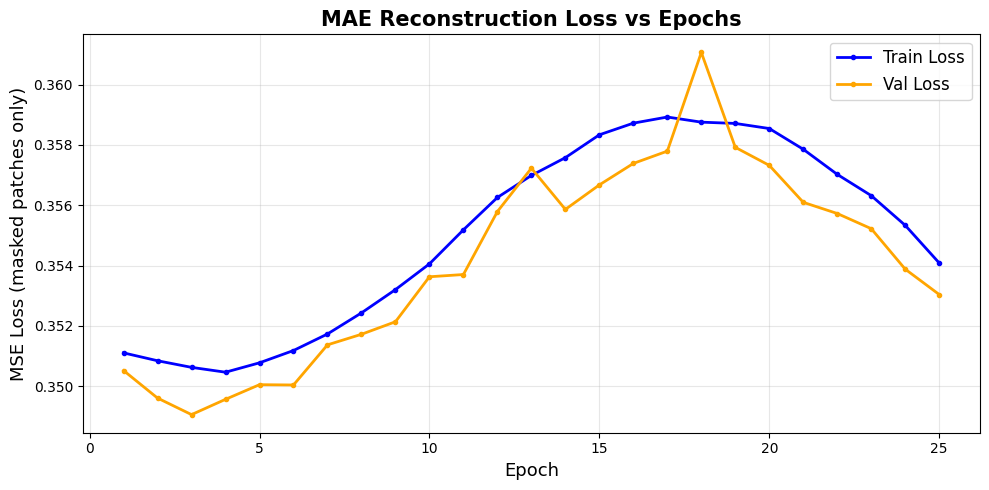

 Loss curve


In [38]:
# Cell 11: Plot Training & Validation Loss

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses,
         label='Train Loss', linewidth=2, color='blue', marker='o', markersize=3)
plt.plot(range(1, len(val_losses) + 1), val_losses,
         label='Val Loss', linewidth=2, color='orange', marker='o', markersize=3)
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('MSE Loss (masked patches only)', fontsize=13)
plt.title('MAE Reconstruction Loss vs Epochs', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print(" Loss curve")

**Visualization**

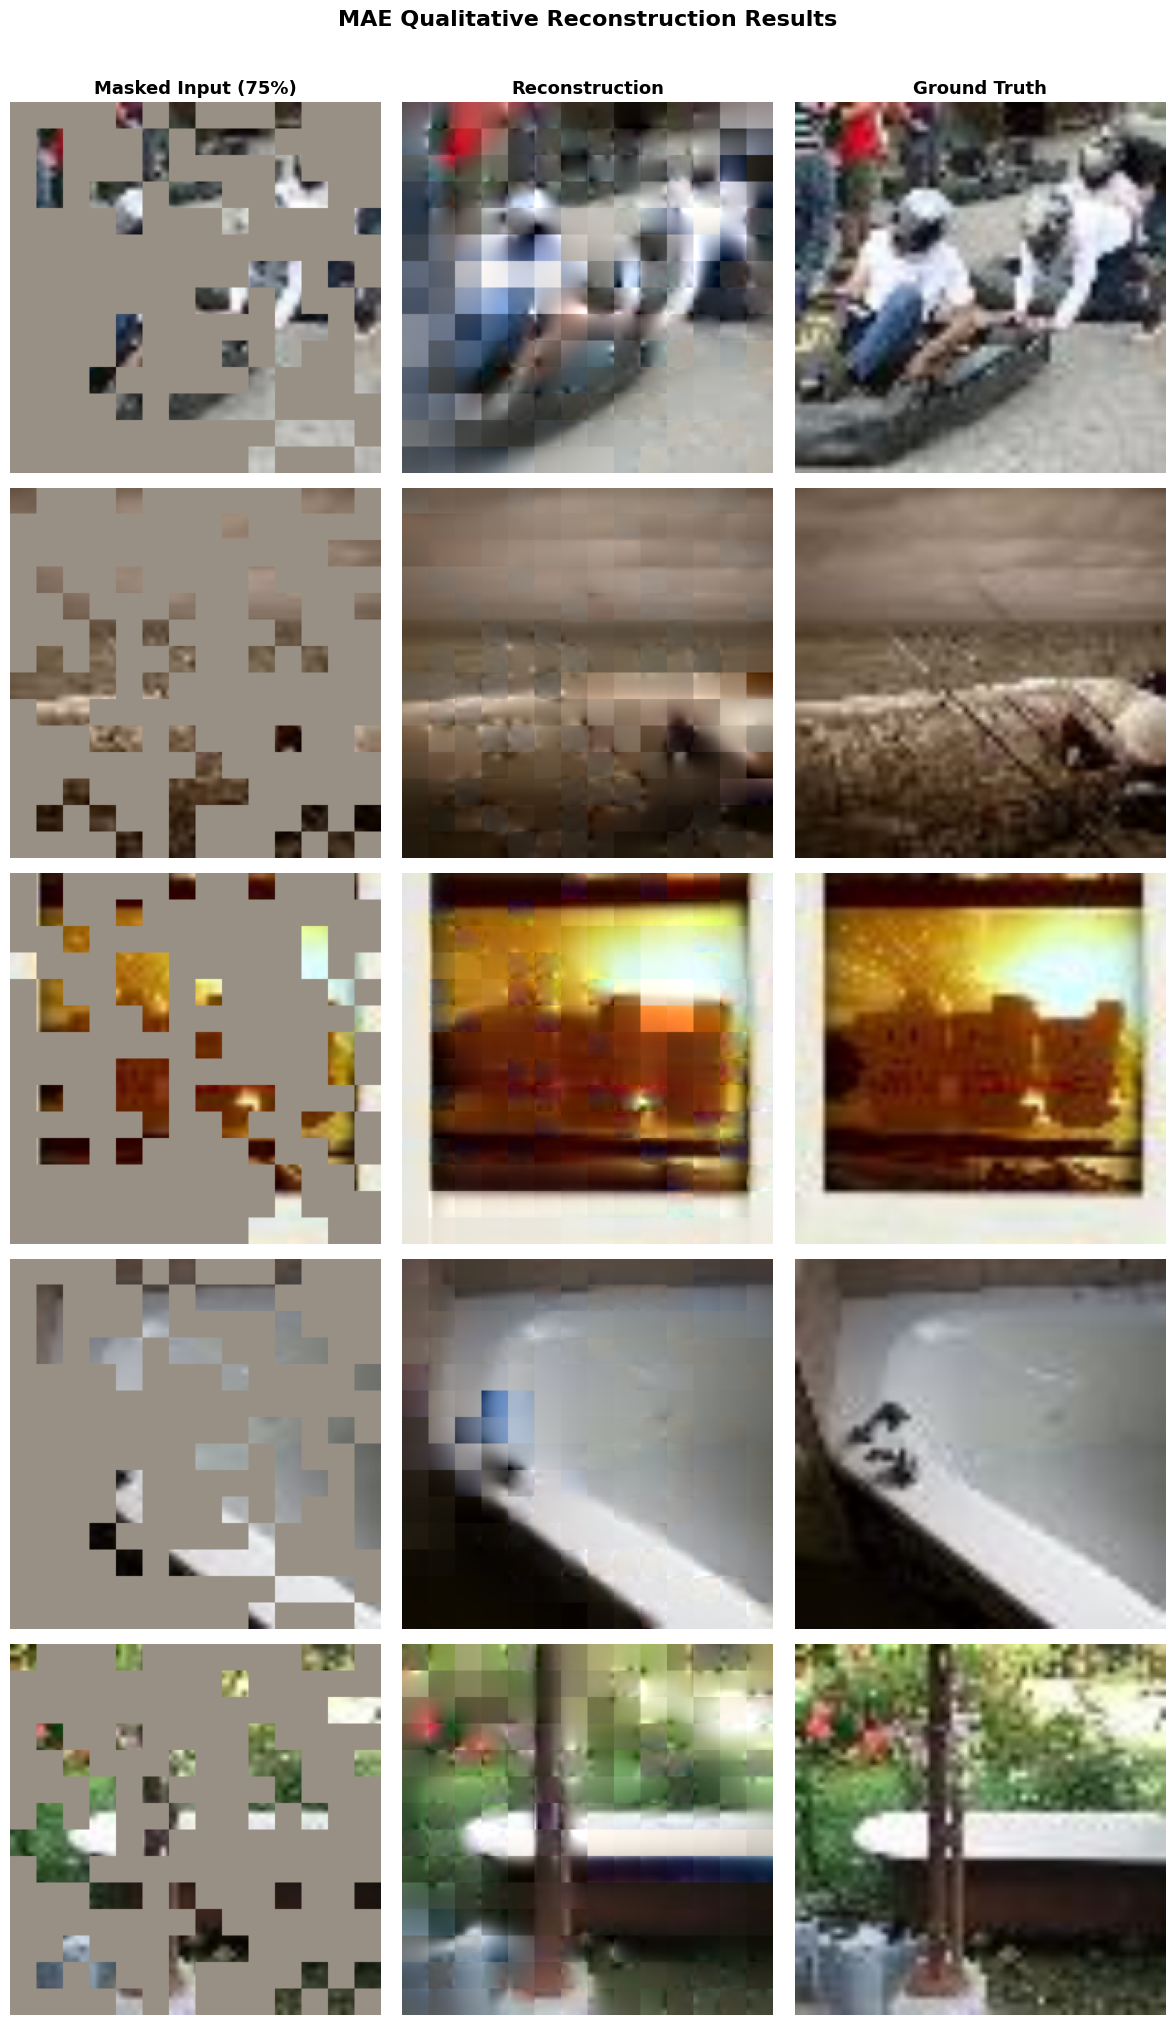

✅ Visualization saved → reconstruction.png


In [40]:
# Cell 12: Visualization — Masked / Reconstructed / Ground Truth

import torch
from torch.amp import autocast as amp_autocast

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])

def denormalize(tensor):
    """(C,H,W) normalized tensor → (H,W,C) numpy float [0,1]"""
    t = tensor.cpu().clone().float()
    t = t * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]
    t = t.clamp(0, 1).permute(1, 2, 0).numpy()
    return t


def visualize_reconstruction(model, loader, n=5,
                              save_path="reconstruction.png"):
    model.eval()

    imgs, _ = next(iter(loader))
    imgs = imgs[:n].to(CFG.device)

    with torch.no_grad():
        with amp_autocast('cuda'):
            _, pred, mask = model(imgs)
        pred = pred.float()
        mask = mask.float()
        imgs = imgs.float()

    # ── Denormalize predictions back to pixel space ───────────────
    orig_patches = patchify(imgs, CFG.patch_size)
    mean_        = orig_patches.mean(dim=-1, keepdim=True)
    var_         = orig_patches.var(dim=-1, keepdim=True)
    pred_denorm  = pred * (var_ + 1e-6).sqrt() + mean_

    # ── Gray out masked patches ───────────────────────────────────
    masked_patches = orig_patches.clone()
    masked_patches[mask.bool()] = 0.5

    # ── Unpatchify ────────────────────────────────────────────────
    orig_imgs   = unpatchify(orig_patches,   CFG.patch_size, CFG.image_size)
    recon_imgs  = unpatchify(pred_denorm,    CFG.patch_size, CFG.image_size)
    masked_imgs = unpatchify(masked_patches, CFG.patch_size, CFG.image_size)

    # ── Plot ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    col_titles = ['Masked Input (75%)', 'Reconstruction', 'Ground Truth']

    for i in range(n):
        for j, img_t in enumerate([masked_imgs[i],
                                    recon_imgs[i],
                                    orig_imgs[i]]):
            axes[i][j].imshow(denormalize(img_t))
            if i == 0:
                axes[i][j].set_title(col_titles[j],
                                     fontsize=13, fontweight='bold')
            axes[i][j].axis('off')

    plt.suptitle('MAE Qualitative Reconstruction Results',
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Visualization saved → {save_path}")


visualize_reconstruction(model, val_loader, n=5)

**PSNR & SSIM**

Quantitative Evaluation (320 samples)
Mean PSNR : 23.5539 dB
Std  PSNR : 3.057 dB
Mean SSIM : 0.6422
Std  SSIM : 0.1195


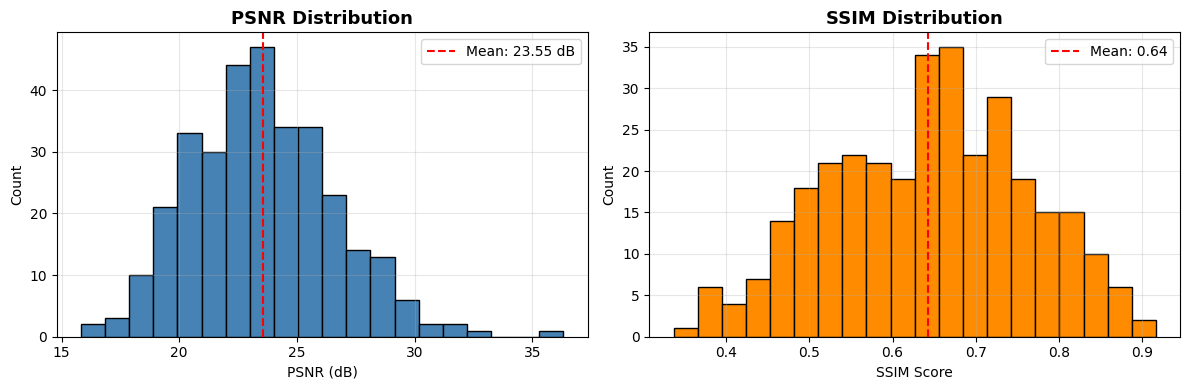

Metrics plot saved -> metrics_distribution.png


In [42]:
# Cell 13: PSNR & SSIM Evaluation

from torch.amp import autocast as amp_autocast
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn
import numpy as np
import matplotlib.pyplot as plt

def compute_metrics(model, loader, n_batches=5):
    model.eval()
    psnr_scores = []
    ssim_scores = []

    with torch.no_grad():
        for i, (imgs, _) in enumerate(loader):
            if i >= n_batches:
                break

            imgs = imgs.to(CFG.device)

            with amp_autocast('cuda'):
                _, pred, mask = model(imgs)

            pred = pred.float()
            imgs = imgs.float()

            orig_patches = patchify(imgs, CFG.patch_size)
            mean_        = orig_patches.mean(dim=-1, keepdim=True)
            var_         = orig_patches.var(dim=-1, keepdim=True)
            pred_denorm  = pred * (var_ + 1e-6).sqrt() + mean_

            orig_imgs  = unpatchify(orig_patches, CFG.patch_size,
                                    CFG.image_size)
            recon_imgs = unpatchify(pred_denorm,  CFG.patch_size,
                                    CFG.image_size)

            for b in range(imgs.shape[0]):
                orig_np  = denormalize(orig_imgs[b])
                recon_np = denormalize(recon_imgs[b])

                p = psnr_fn(orig_np, recon_np, data_range=1.0)
                s = ssim_fn(orig_np, recon_np,
                            data_range=1.0,
                            channel_axis=2,
                            win_size=7)
                psnr_scores.append(p)
                ssim_scores.append(s)

    print("=" * 50)
    print("Quantitative Evaluation (" + str(len(psnr_scores)) + " samples)")
    print("=" * 50)
    print("Mean PSNR : " + str(round(np.mean(psnr_scores), 4)) + " dB")
    print("Std  PSNR : " + str(round(np.std(psnr_scores),  4)) + " dB")
    print("Mean SSIM : " + str(round(np.mean(ssim_scores), 4)))
    print("Std  SSIM : " + str(round(np.std(ssim_scores),  4)))
    print("=" * 50)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(psnr_scores, bins=20,
                 color='steelblue', edgecolor='black')
    axes[0].set_title('PSNR Distribution', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('PSNR (dB)')
    axes[0].set_ylabel('Count')
    axes[0].axvline(np.mean(psnr_scores), color='red',
                    linestyle='--',
                    label='Mean: ' + str(round(np.mean(psnr_scores), 2)) + ' dB')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(ssim_scores, bins=20,
                 color='darkorange', edgecolor='black')
    axes[1].set_title('SSIM Distribution', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('SSIM Score')
    axes[1].set_ylabel('Count')
    axes[1].axvline(np.mean(ssim_scores), color='red',
                    linestyle='--',
                    label='Mean: ' + str(round(np.mean(ssim_scores), 2)))
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('metrics_distribution.png', dpi=150)
    plt.show()
    print("Metrics plot saved -> metrics_distribution.png")

    return psnr_scores, ssim_scores


psnr_scores, ssim_scores = compute_metrics(model, val_loader)

**Save Checkpoint**

In [43]:
# Cell 14: Save Final Checkpoint

import os

torch.save({
    'epoch'         : CFG.epochs,
    'model_state'   : get_model().state_dict(),
    'optim_state'   : optimizer.state_dict(),
    'train_losses'  : train_losses,
    'val_losses'    : val_losses,
    'best_val_loss' : best_val_loss,
}, 'mae_checkpoint.pth')

print("Final checkpoint saved  -> mae_checkpoint.pth")
print("Best model saved        -> mae_best.pth")
print("Best Validation Loss    -> " + str(round(best_val_loss, 4)))
print("mae_checkpoint exists   -> " + str(os.path.exists('mae_checkpoint.pth')))
print("mae_best exists         -> " + str(os.path.exists('mae_best.pth')))

Final checkpoint saved  -> mae_checkpoint.pth
Best model saved        -> mae_best.pth
Best Validation Loss    -> 0.3491
mae_checkpoint exists   -> True
mae_best exists         -> True


** Gradio App**

In [44]:
# Cell 15: Gradio App

import gradio as gr
from PIL import Image
from torchvision import transforms
import numpy as np
import torch

def load_trained_model():
    m = MAE()
    ckpt = torch.load('mae_best.pth', map_location='cpu')
    m.load_state_dict(ckpt)
    m.eval()
    return m

app_model = load_trained_model()
print("Model loaded for Gradio app")

def reconstruct_image(pil_img, mask_ratio_val):
    transform = transforms.Compose([
        transforms.Resize((CFG.image_size, CFG.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])

    img_tensor = transform(pil_img).unsqueeze(0)

    with torch.no_grad():

        patches = patchify(img_tensor, CFG.patch_size)
        x = app_model.encoder.patch_embed(patches)
        x = x + app_model.encoder.pos_embed[:, 1:, :]

        x_vis, mask, ids_restore = random_masking(x, mask_ratio_val)

        cls = app_model.encoder.cls_token.expand(1, -1, -1)
        cls = cls + app_model.encoder.pos_embed[:, :1, :]
        x_vis = torch.cat([cls, x_vis], dim=1)

        for blk in app_model.encoder.blocks:
            x_vis = blk(x_vis)
        x_vis = app_model.encoder.norm(x_vis)

        pred = app_model.decoder(x_vis, ids_restore)
        pred = pred.float()

    orig_patches   = patchify(img_tensor, CFG.patch_size)
    mean_          = orig_patches.mean(dim=-1, keepdim=True)
    var_           = orig_patches.var(dim=-1, keepdim=True)
    pred_denorm    = pred * (var_ + 1e-6).sqrt() + mean_

    masked_patches = orig_patches.clone()
    masked_patches[mask.bool()] = 0.5

    orig_img   = unpatchify(orig_patches,
                            CFG.patch_size, CFG.image_size)[0]
    recon_img  = unpatchify(pred_denorm,
                            CFG.patch_size, CFG.image_size)[0]
    masked_img = unpatchify(masked_patches,
                            CFG.patch_size, CFG.image_size)[0]

    def to_pil(t):
        arr = denormalize(t)
        arr = (arr * 255).astype(np.uint8)
        return Image.fromarray(arr)

    return to_pil(masked_img), to_pil(recon_img), to_pil(orig_img)


with gr.Blocks(title="MAE Reconstruction") as demo:
    gr.Markdown("# MAE - Masked Autoencoder Image Reconstruction")
    gr.Markdown(
        "Upload an image, select a masking ratio, "
        "and see the MAE reconstruct it in real time."
    )

    with gr.Row():
        img_input   = gr.Image(type="pil", label="Upload Image")
        mask_slider = gr.Slider(
            minimum=0.1,
            maximum=0.9,
            value=0.75,
            step=0.05,
            label="Masking Ratio"
        )

    btn = gr.Button("Reconstruct", variant="primary")

    with gr.Row():
        out_masked = gr.Image(label="Masked Input")
        out_recon  = gr.Image(label="Reconstruction")
        out_orig   = gr.Image(label="Ground Truth")

    btn.click(
        fn=reconstruct_image,
        inputs=[img_input, mask_slider],
        outputs=[out_masked, out_recon, out_orig]
    )

demo.launch(share=True)

Model loaded for Gradio app
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://08c7e3b968a8e87680.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [45]:
# Run this in Kaggle to check files are there
import os

files = ['mae_best.pth', 'mae_checkpoint.pth', 
         'loss_curve.png', 'reconstruction.png',
         'metrics_distribution.png']

for f in files:
    size = os.path.getsize(f) / (1024*1024) if os.path.exists(f) else 0
    print(f"{f}: {'EXISTS' if os.path.exists(f) else 'MISSING'} | {size:.1f} MB")

mae_best.pth: EXISTS | 411.2 MB
mae_checkpoint.pth: EXISTS | 1231.8 MB
loss_curve.png: EXISTS | 0.1 MB
reconstruction.png: EXISTS | 2.5 MB
metrics_distribution.png: EXISTS | 0.0 MB


In [46]:
# Zip all important files for download
import zipfile
import os

files_to_zip = [
    'mae_best.pth',
    'loss_curve.png', 
    'reconstruction.png',
    'metrics_distribution.png'
]

with zipfile.ZipFile('mae_project.zip', 'w') as zf:
    for f in files_to_zip:
        if os.path.exists(f):
            zf.write(f)
            print("Added: " + f)

size = os.path.getsize('mae_project.zip') / (1024*1024)
print("ZIP created -> mae_project.zip | " + str(round(size, 1)) + " MB")

Added: mae_best.pth
Added: loss_curve.png
Added: reconstruction.png
Added: metrics_distribution.png
ZIP created -> mae_project.zip | 413.8 MB
